## 1. Imports

In [34]:
import os
import pickle                          
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB            
from sklearn.ensemble import (
    RandomForestClassifier,
    VotingClassifier,
    BaggingClassifier,
    StackingClassifier,
)
import xgboost as xgb
import lightgbm as lgb
warnings.filterwarnings('ignore')
np.random.seed(42)

## 2. Configuration

In [35]:
REPO_ROOT    = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR     = os.path.join(REPO_ROOT, 'Datasets_all')
OUT_DIR      = Path('models')
OUT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
N_SPLITS     = 5
CHAMPION_F1  = 0.6110   # Score from A4 

## 3. Load Data

In [36]:
movement_features_df = pd.read_csv(os.path.join(DATA_DIR, 'aimoscores.csv'))
weaklink_scores_df   = pd.read_csv(os.path.join(DATA_DIR, 'scores_and_weaklink.csv'))

print('Movement features shape:', movement_features_df.shape)
print('Weak link scores shape:', weaklink_scores_df.shape)

Movement features shape: (2094, 43)
Weak link scores shape: (2096, 17)


## 4. Remove Duplicate Columns 

In [37]:
DUPLICATE_NASM_COLS = [
    'No_1_NASM_Deviation',   
    'No_2_NASM_Deviation',   
    'No_3_NASM_Deviation',   
    'No_4_NASM_Deviation',   
    'No_5_NASM_Deviation', 
]

movement_features_df = movement_features_df.drop(columns=DUPLICATE_NASM_COLS)
print('Shape after duplicate removal:', movement_features_df.shape)

Shape after duplicate removal: (2094, 38)


## 5. Build Classification Target (WeakestLink)

In [38]:
weaklink_categories = [
    'ExcessiveForwardLean', 'ForwardHead', 'LeftArmFallForward',
    'LeftAsymmetricalWeightShift', 'LeftHeelRises', 'LeftKneeMovesInward',
    'LeftKneeMovesOutward', 'LeftShoulderElevation', 'RightArmFallForward',
    'RightAsymmetricalWeightShift', 'RightHeelRises', 'RightKneeMovesInward',
    'RightKneeMovesOutward', 'RightShoulderElevation',
]

weaklink_scores_df['WeakestLink'] = (
    weaklink_scores_df[weaklink_categories].idxmax(axis=1)
)
print('Weakest Link class distribution:')
print(weaklink_scores_df['WeakestLink'].value_counts())

Weakest Link class distribution:
WeakestLink
LeftArmFallForward              616
RightArmFallForward             458
RightKneeMovesOutward           274
RightShoulderElevation          245
ExcessiveForwardLean            128
ForwardHead                     109
LeftAsymmetricalWeightShift      80
LeftShoulderElevation            55
LeftKneeMovesOutward             54
RightKneeMovesInward             45
RightAsymmetricalWeightShift     20
LeftHeelRises                     7
LeftKneeMovesInward               3
RightHeelRises                    2
Name: count, dtype: int64


## 6. Merge Datasets & Visualise Class Imbalance

Merged dataset shape: (2094, 39)


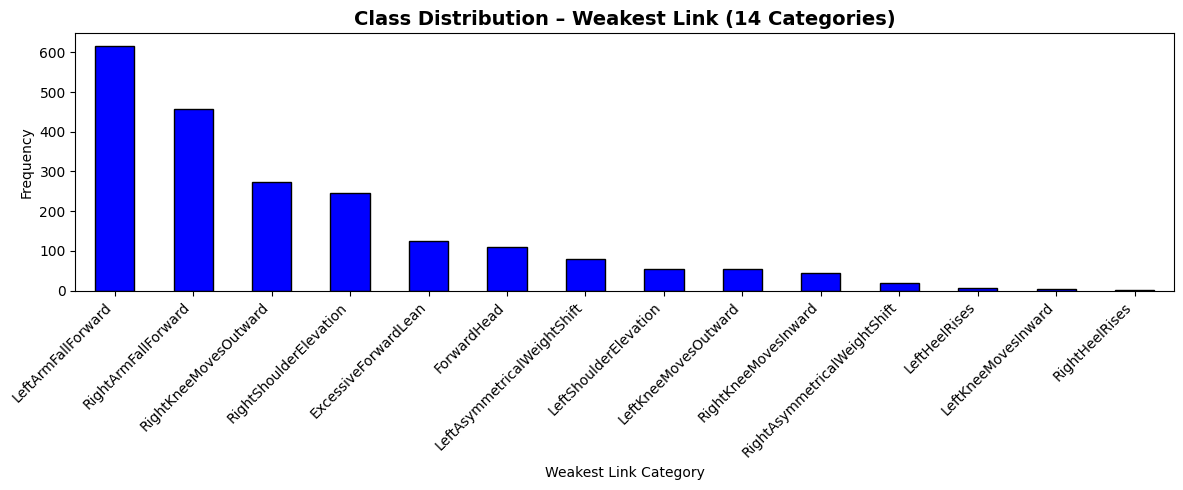

In [39]:
target_df = weaklink_scores_df[['ID', 'WeakestLink']].copy()
merged_df = movement_features_df.merge(target_df, on='ID', how='inner')
print('Merged dataset shape:', merged_df.shape) 

plt.figure(figsize=(12, 5))
merged_df['WeakestLink'].value_counts().plot(
    kind='bar', color='blue', edgecolor='black'
)
plt.title('Class Distribution – Weakest Link (14 Categories)',
          fontsize=14, fontweight='bold')
plt.xlabel('Weakest Link Category')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 7. Prepare Features

In [40]:
EXCLUDE_COLS    = ['ID', 'WeakestLink', 'EstimatedScore']
feature_columns = [c for c in merged_df.columns if c not in EXCLUDE_COLS]

X = merged_df[feature_columns].values
y = merged_df['WeakestLink'].values

print(f'Feature matrix shape : {X.shape}')
print(f'Number of features   : {len(feature_columns)}')
print(f'Number of classes    : {len(np.unique(y))}')

Feature matrix shape : (2094, 36)
Number of features   : 36
Number of classes    : 14


## 8. Train and Test Split + Scaling

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')

Training samples : 1675
Test samples     : 419


## 9. CV Evaluation

In [42]:
cv_strategy = StratifiedKFold(
    n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE
)

def evaluate_cv(model, X, y, cv, name='Model'):
    scoring = {
        'accuracy' : 'accuracy',
        'f1'       : 'f1_weighted',
        'precision': 'precision_weighted',
        'recall'   : 'recall_weighted',
    }
    cv_res = cross_validate(model, X, y, cv=cv, scoring=scoring)
    return {
        'Model'         : name,
        'Accuracy_mean' : cv_res['test_accuracy'].mean(),
        'Accuracy_std'  : cv_res['test_accuracy'].std(),
        'F1_mean'       : cv_res['test_f1'].mean(),
        'F1_std'        : cv_res['test_f1'].std(),
        'Precision_mean': cv_res['test_precision'].mean(),
        'Recall_mean'   : cv_res['test_recall'].mean(),
        '_f1_scores'    : cv_res['test_f1'], 
    }

## 10. A4 Champion Baseline (Random Forest)

In [59]:
rf_champion = RandomForestClassifier(
    n_estimators=200, max_depth=15,
    min_samples_split=5, min_samples_leaf=2,
    class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1
)
champ_cv = evaluate_cv(
    rf_champion, X_train_scaled, y_train, cv_strategy,
    name='A4 Champion – Random Forest'
)
rf_champion.fit(X_train_scaled, y_train)
champ_test_f1 = f1_score(y_test, rf_champion.predict(X_test_scaled), average='weighted')

print('A4 CHAMPION (Random Forest)')
print(f'CV F1: {champ_cv["F1_mean"]:.4f} +/- {champ_cv["F1_std"]:.4f}')
print(f'Test F1: {champ_test_f1:.4f}')

A4 CHAMPION (Random Forest)
CV F1: 0.6058 +/- 0.0289
Test F1: 0.6141


## 11. Ensemble 1 – Hard Voting

In [65]:
hard_voting = VotingClassifier(
    estimators=[
        ('rf',  RandomForestClassifier( n_estimators=200, max_depth=15, min_samples_split=5, min_samples_leaf=2, class_weight='balanced_subsample', 
                                        random_state=RANDOM_STATE, n_jobs=-1)),
        ('lr',  LogisticRegression( max_iter=1000, class_weight='balanced',random_state=RANDOM_STATE)),
        ('xgb', xgb.XGBClassifier(  n_estimators=200, max_depth=6, learning_rate=0.1, subsample=0.8,
                                    colsample_bytree=0.8, random_state=RANDOM_STATE,class_weight='balanced', n_jobs=-1 )),
        ('lgb', lgb.LGBMClassifier(n_estimators=200, learning_rate=0.1, subsample=0.8,
                                   colsample_bytree=0.8, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)),
        ('knn', KNeighborsClassifier(n_neighbors=7)),
        ('lda', LinearDiscriminantAnalysis()),
    ],
    voting='hard',
    n_jobs=-1,
)

hv_cv = evaluate_cv(hard_voting, X_train_scaled, y_train, cv_strategy, name='Hard Voting')
print(f'Hard Voting CV F1: {hv_cv["F1_mean"]:.4f} +/- {hv_cv["F1_std"]:.4f}')

Hard Voting CV F1: 0.6310 +/- 0.0148


## 12. Ensemble 2 – Soft Voting

In [66]:
soft_voting = VotingClassifier(
    estimators=[
        ('rf',  RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_split=5, min_samples_leaf=2, class_weight='balanced_subsample', 
                                       random_state=RANDOM_STATE, n_jobs=-1)),
        ('lr',  LogisticRegression( max_iter=1000, class_weight='balanced',random_state=RANDOM_STATE)),      
        ('xgb', xgb.XGBClassifier(  n_estimators=200, max_depth=6, learning_rate=0.1, subsample=0.8,
                                    colsample_bytree=0.8, random_state=RANDOM_STATE,class_weight='balanced', n_jobs=-1 )),
        ('lgb', lgb.LGBMClassifier( n_estimators=200, learning_rate=0.1, class_weight='balanced',subsample=0.8, colsample_bytree=0.8,
                                    random_state=RANDOM_STATE, n_jobs=-1 )),
        ('knn', KNeighborsClassifier(n_neighbors=7)),  
        ('lda', LinearDiscriminantAnalysis()),
    ],
    voting='soft',
    n_jobs=-1,
)

sv_cv = evaluate_cv(soft_voting, X_train_scaled, y_train, cv_strategy, name='Soft Voting')
print(f'Soft Voting CV F1: {sv_cv["F1_mean"]:.4f} +/- {sv_cv["F1_std"]:.4f}')

Soft Voting CV F1: 0.6365 +/- 0.0181


## 13. Ensemble 3 – Bootstrap Bagging on LDA

In [62]:
bagging_lda = BaggingClassifier(
    estimator=LinearDiscriminantAnalysis(),
    n_estimators=50,      
    max_samples=0.8,
    max_features=0.9,
    bootstrap=True,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

bag_cv = evaluate_cv(bagging_lda, X_train_scaled, y_train, cv_strategy,
                     name='Bootstrap Bagging (LDA)')
print(f'Bagging LDA CV F1: {bag_cv["F1_mean"]:.4f} +/- {bag_cv["F1_std"]:.4f}')

Bagging LDA CV F1: 0.5653 +/- 0.0249


## 14. Ensemble 4 – Stacking

In [64]:
stacking = StackingClassifier(
    estimators=[
        ('rf',   RandomForestClassifier( n_estimators=100, max_depth=15,min_samples_split=5, min_samples_leaf=2,class_weight='balanced_subsample',
                     random_state=RANDOM_STATE, n_jobs=-1)),
        ('lr',  LogisticRegression( max_iter=1000, class_weight='balanced',random_state=RANDOM_STATE)),     
        ('knn', KNeighborsClassifier(n_neighbors=7)),  
        ('lda', LinearDiscriminantAnalysis()),
        
    ],
    final_estimator=LogisticRegression(
        C=1.0, max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE
    ),
    cv=5,
    passthrough=False,
    n_jobs=-1,
)

st_cv = evaluate_cv(stacking, X_train_scaled, y_train, cv_strategy,
                    name='Stacking (LR meta)')
print(f'Stacking CV F1: {st_cv["F1_mean"]:.4f} +/- {st_cv["F1_std"]:.4f}')

Stacking CV F1: 0.5985 +/- 0.0159


## 15. CV Summary Comparison

In [67]:
all_results = [champ_cv, hv_cv, sv_cv, bag_cv, st_cv]
results_df  = (
    pd.DataFrame([{k: v for k, v in r.items() if k != '_f1_scores'}
                  for r in all_results])
    .sort_values('F1_mean', ascending=False)
    .reset_index(drop=True)
)

print('5-FOLD CROSS-VALIDATION SUMMARY')
print(results_df[['Model','F1_mean','F1_std','Accuracy_mean',
                   'Precision_mean','Recall_mean']].to_string(index=False))

5-FOLD CROSS-VALIDATION SUMMARY
                      Model  F1_mean   F1_std  Accuracy_mean  Precision_mean  Recall_mean
                Soft Voting 0.636505 0.018089       0.647164        0.641519     0.647164
                Hard Voting 0.630970 0.014828       0.645373        0.631015     0.645373
A4 Champion – Random Forest 0.605816 0.028917       0.621493        0.602919     0.621493
         Stacking (LR meta) 0.598453 0.015950       0.574925        0.656129     0.574925
    Bootstrap Bagging (LDA) 0.565322 0.024937       0.575522        0.566827     0.575522


## 16. Visualise CV Results

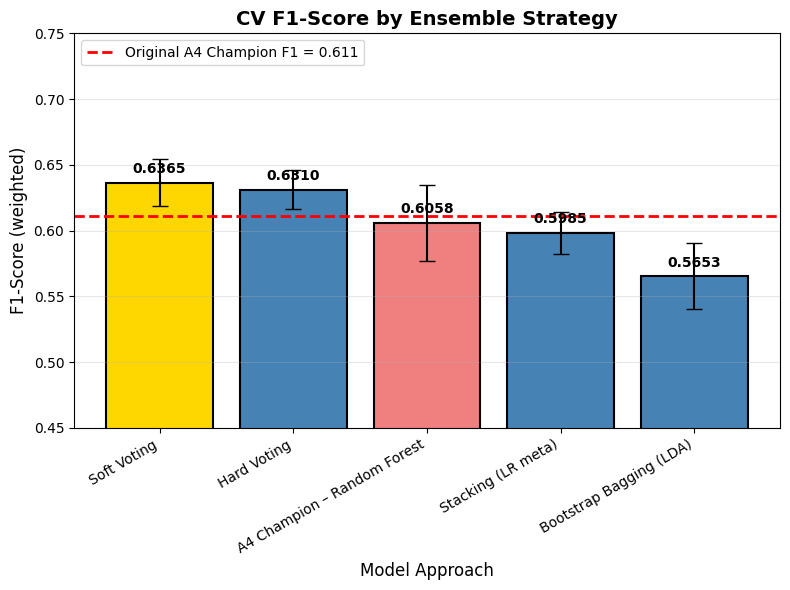

In [69]:
fig, ax = plt.subplots(figsize=(8, 6))

# Prepare data
models  = results_df['Model']
f1_mean = results_df['F1_mean']
f1_std  = results_df['F1_std']

colors  = ['gold' if m == results_df.iloc[0]['Model']
           else ('lightcoral' if 'Champion' in m else 'steelblue')
           for m in models]

# Plot bars
bars = ax.bar(models, f1_mean, yerr=f1_std, capsize=6,
              color=colors, edgecolor='black', linewidth=1.5)

# horizontal reference line for the previous champion
ax.axhline(CHAMPION_F1, color='red', linestyle='--', linewidth=2,
           label=f'Original A4 Champion F1 = {CHAMPION_F1}')

ax.set_ylim([0.45, 0.75]) 
ax.set_title('CV F1-Score by Ensemble Strategy', fontsize=14, fontweight='bold')
ax.set_ylabel('F1-Score (weighted)', fontsize=12)
ax.set_xlabel('Model Approach', fontsize=12)

ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=30, ha='right')

for bar, val in zip(bars, f1_mean):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005, f'{val:.4f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 17. Statistical Significance Test (t-test)

In [77]:
def corrected_resampled_ttest(scores_a, scores_b, n_train, n_test):
    k        = len(scores_a)
    diff     = scores_a - scores_b
    d_bar    = diff.mean()
    s_sq     = diff.var(ddof=1)
    var_corr = (1/k + n_test/n_train) * s_sq
    t_stat   = d_bar / np.sqrt(var_corr)
    p_value  = 2 * (1 - stats.t.cdf(abs(t_stat), df=k-1))
    return float(t_stat), float(p_value)

n_total      = len(X_train_scaled)
n_test_fold  = n_total // N_SPLITS
n_train_fold = n_total - n_test_fold

result_map   = {r['Model']: r['_f1_scores'] for r in all_results}
champ_scores = result_map['A4 Champion – Random Forest']

print('STATISTICAL SIGNIFICANCE TESTS vs A4 Champion')
for r in all_results:
    if 'Champion' in r['Model']:
        continue
    t, p = corrected_resampled_ttest(
        r['_f1_scores'], champ_scores, n_train_fold, n_test_fold
    )
    print(f'  {r["Model"]:<35}  t={t:+.3f}  p={p:.4f}')

STATISTICAL SIGNIFICANCE TESTS vs A4 Champion
  Hard Voting                          t=+1.339  p=0.2516
  Soft Voting                          t=+1.632  p=0.1781
  Bootstrap Bagging (LDA)              t=-5.123  p=0.0069
  Stacking (LR meta)                   t=-0.556  p=0.6078


## 18. Select Champion Ensemble & Final Test-Set Evaluation

In [71]:
model_objects = {
    'Hard Voting'                : hard_voting,
    'Soft Voting'                : soft_voting,       
    'Bootstrap Bagging (LDA)'    : bagging_lda,
    'Stacking (LR meta)'         : stacking,
    'A4 Champion – Random Forest': rf_champion,      
}

best_name  = results_df.iloc[0]['Model']
best_model = model_objects[best_name]

print(f'CHAMPION ENSEMBLE: {best_name}')
print(f'CV F1 : {results_df.iloc[0]["F1_mean"]:.4f} +/- {results_df.iloc[0]["F1_std"]:.4f}')

best_model.fit(X_train_scaled, y_train)
y_pred_best = best_model.predict(X_test_scaled)

test_f1   = f1_score(y_test, y_pred_best, average='weighted')
test_acc  = accuracy_score(y_test, y_pred_best)
test_prec = precision_score(y_test, y_pred_best, average='weighted', zero_division=0)
test_rec  = recall_score(y_test, y_pred_best, average='weighted', zero_division=0)
improvement = (test_f1 - CHAMPION_F1) / CHAMPION_F1 * 100

print('\n TEST SET RESULTS')
print(f'F1-Score (weighted) : {test_f1:.4f}')
print(f'Accuracy  : {test_acc:.4f}')
print(f'Precision : {test_prec:.4f}')
print(f'Recall : {test_rec:.4f}')
print(f'\n A4 original champion F1 : {CHAMPION_F1:.4f}')

CHAMPION ENSEMBLE: Soft Voting
CV F1 : 0.6365 +/- 0.0181

 TEST SET RESULTS
F1-Score (weighted) : 0.6419
Accuracy  : 0.6492
Precision : 0.6492
Recall : 0.6492

 A4 original champion F1 : 0.6110


## 19. All Models – Test Set Comparison Table

In [72]:
test_rows = []
for name, model in model_objects.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    test_rows.append({
        'Model'      : name,
        'Test_F1'    : f1_score(y_test, preds, average='weighted'),
        'Test_Acc'   : accuracy_score(y_test, preds),
        'Test_Prec'  : precision_score(y_test, preds, average='weighted', zero_division=0),
        'Test_Recall': recall_score(y_test, preds, average='weighted', zero_division=0),
    })

test_results_df = pd.DataFrame(test_rows).sort_values('Test_F1', ascending=False)
print('TEST SET COMPARISON – ALL MODELS')
print(test_results_df.to_string(index=False))

TEST SET COMPARISON – ALL MODELS
                      Model  Test_F1  Test_Acc  Test_Prec  Test_Recall
                Hard Voting 0.645079  0.653938   0.654667     0.653938
                Soft Voting 0.641883  0.649165   0.649217     0.649165
A4 Champion – Random Forest 0.614147  0.618138   0.644145     0.618138
         Stacking (LR meta) 0.591951  0.572792   0.650306     0.572792
    Bootstrap Bagging (LDA) 0.568919  0.575179   0.579848     0.575179


## 20. Visualise Final Test-Set Results

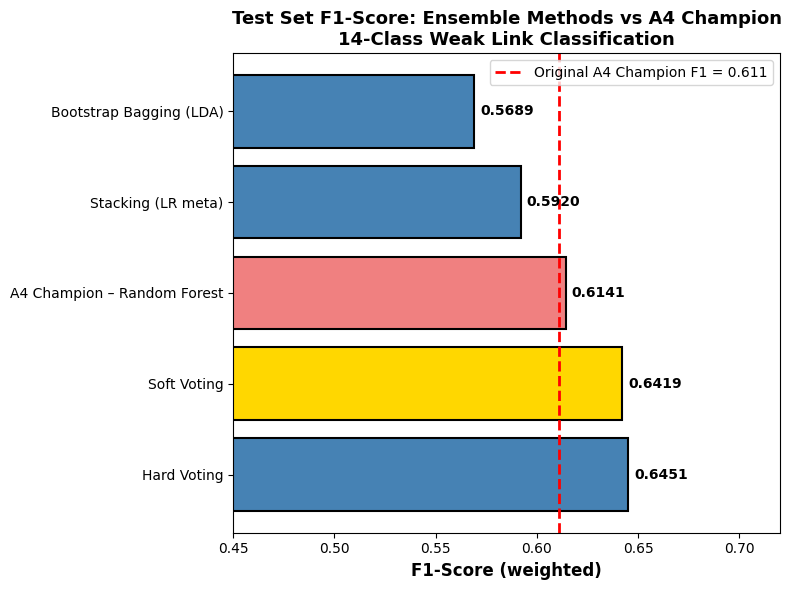

In [73]:
fig, ax = plt.subplots(figsize=(8, 6))
t_models   = test_results_df['Model']
t_f1       = test_results_df['Test_F1']
bar_colors = [
    'gold' if m == best_name else
    ('lightcoral' if 'Champion' in m else 'steelblue')
    for m in t_models
]
bars = ax.barh(t_models, t_f1, color=bar_colors, edgecolor='black', linewidth=1.5)
ax.axvline(CHAMPION_F1, color='red', linestyle='--', linewidth=2,
           label=f'Original A4 Champion F1 = {CHAMPION_F1}')
ax.set_xlabel('F1-Score (weighted)', fontsize=12, fontweight='bold')
ax.set_title(
    'Test Set F1-Score: Ensemble Methods vs A4 Champion\n'
    '14-Class Weak Link Classification',
    fontsize=13, fontweight='bold'
)
ax.legend()
ax.set_xlim([0.45, 0.72])
for bar, val in zip(bars, t_f1):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

## 21. Detailed Classification Report – Champion Ensemble

In [74]:
print(f'CLASSIFICATION REPORT: {best_name}')
print(classification_report(y_test, y_pred_best, zero_division=0))

CLASSIFICATION REPORT: Soft Voting
                              precision    recall  f1-score   support

        ExcessiveForwardLean       0.51      0.88      0.65        25
                 ForwardHead       0.87      0.59      0.70        22
          LeftArmFallForward       0.69      0.68      0.69       123
 LeftAsymmetricalWeightShift       0.62      0.62      0.62        16
               LeftHeelRises       0.00      0.00      0.00         1
         LeftKneeMovesInward       0.00      0.00      0.00         1
        LeftKneeMovesOutward       0.50      0.18      0.27        11
       LeftShoulderElevation       0.20      0.09      0.12        11
         RightArmFallForward       0.58      0.61      0.59        92
RightAsymmetricalWeightShift       0.40      0.50      0.44         4
        RightKneeMovesInward       0.50      0.33      0.40         9
       RightKneeMovesOutward       0.91      0.91      0.91        55
      RightShoulderElevation       0.57      0.59     

## 22. Confusion Matrix – Champion Ensemble

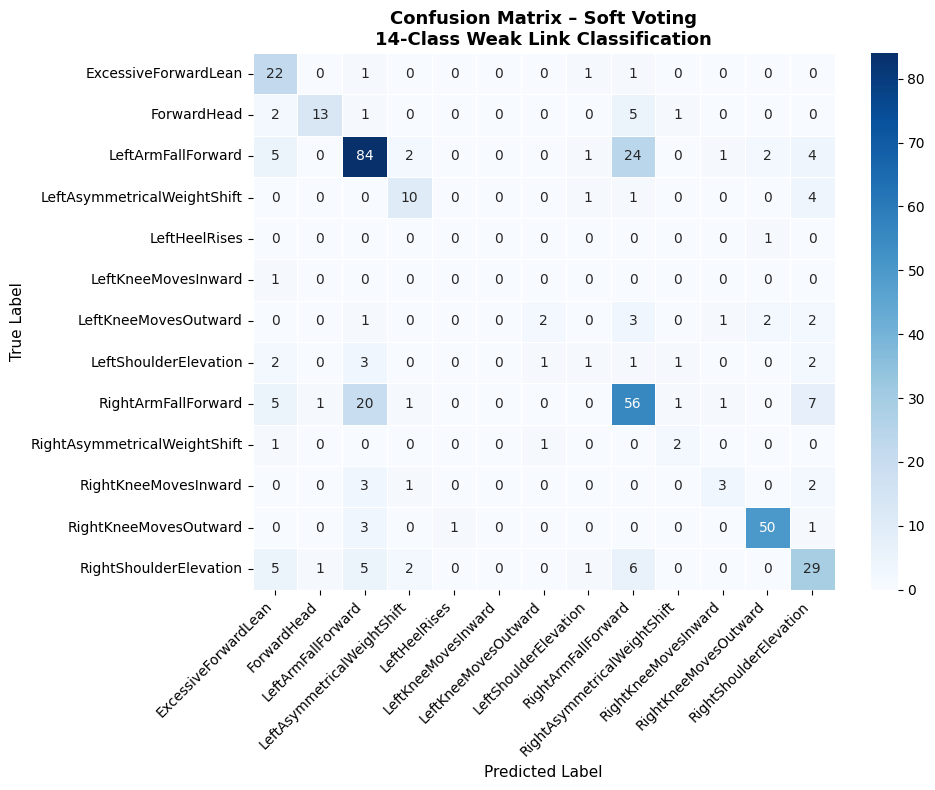

In [75]:
class_labels = sorted(np.unique(y_test))
cm = confusion_matrix(y_test, y_pred_best, labels=class_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels, linewidths=0.5)
plt.title(f'Confusion Matrix – {best_name}\n14-Class Weak Link Classification',
          fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('True Label', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 24. Save Champion Ensemble

In [76]:
artifact = {
    'model'                  : best_model,
    'model_name'             : best_name,
    'scaler'                 : scaler,
    'feature_columns'        : feature_columns,
    'cv_metrics': {
        'f1_mean'      : float(results_df.iloc[0]['F1_mean']),
        'f1_std'       : float(results_df.iloc[0]['F1_std']),
        'accuracy_mean': float(results_df.iloc[0]['Accuracy_mean']),
    },
    'test_metrics': {
        'f1'       : float(test_f1),
        'accuracy' : float(test_acc),
        'precision': float(test_prec),
        'recall'   : float(test_rec),
    },
    'a4_champion_f1' : CHAMPION_F1,
    'improvement_pct': float(improvement),
}

out_path = OUT_DIR / 'ensemble_classification_champion.pkl'
with open(out_path, 'wb') as f:
    pickle.dump(artifact, f)

print(f'Saved: {out_path}')

Saved: models\ensemble_classification_champion.pkl
